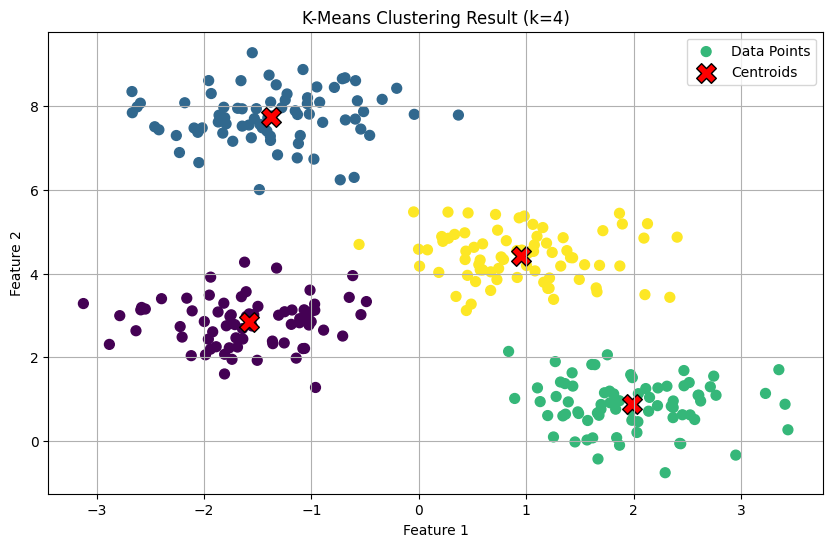

In [1]:
#bai 1
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def initialize_centroids(X, k):
    """Randomly initializes k centroids from the dataset."""
    indices = np.random.choice(X.shape[0], k, replace=False)
    return X[indices]

def assign_to_clusters(X, centroids):
    """Assigns each data point to the closest centroid."""
    distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
    return np.argmin(distances, axis=0)

def update_centroids(X, assignments, k):
    """Recalculates the centroids based on the mean of points in each cluster."""
    new_centroids = np.array([X[assignments == i].mean(axis=0) if np.sum(assignments == i) > 0 else centroids[i] for i in range(k)])
    return new_centroids

def kmeans(X, k, max_iterations=100):
    """Performs k-means clustering iterations."""
    centroids = initialize_centroids(X, k)
    for _ in range(max_iterations):
        assignments = assign_to_clusters(X, centroids)
        new_centroids = update_centroids(X, assignments, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return assignments, centroids

# 1. Khởi tạo dữ liệu mẫu
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# 2. Chạy thuật toán K-Means
k = 4
assignments, centroids = kmeans(X, k)

# 3. Hiển thị kết quả
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=assignments, s=50, cmap='viridis', label='Data Points')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids', edgecolor='black')
plt.title(f'K-Means Clustering Result (k={k})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

Accuracy (Uniform): 80.00%
Accuracy (Distance): 85.00%


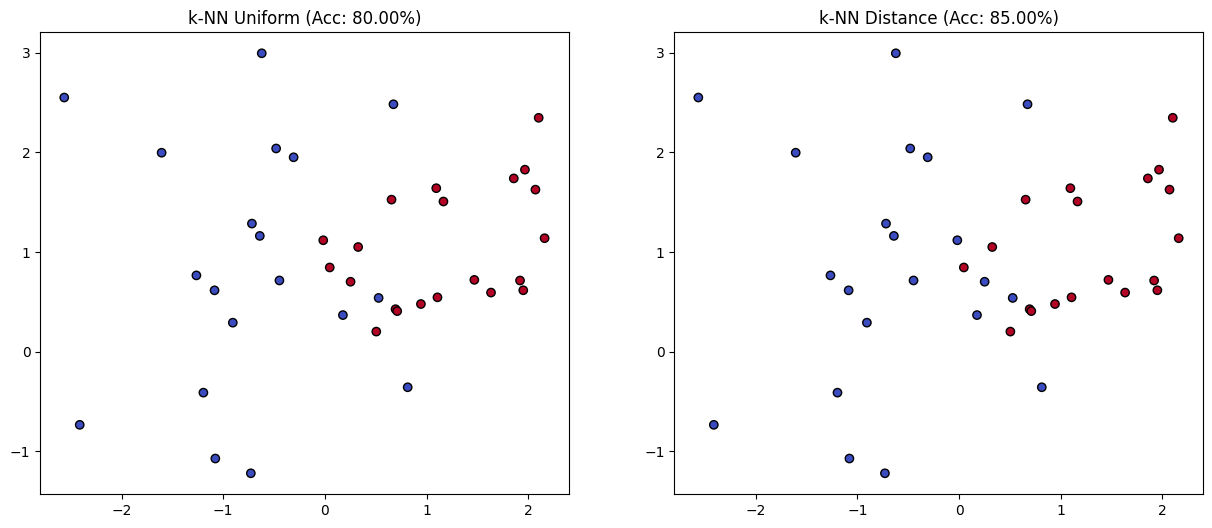

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from collections import Counter

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

class KNN:
    def __init__(self, k=3, weights='uniform'):
        self.k = k
        self.weights = weights

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        # Tính khoảng cách từ x đến tất cả các điểm trong tập train
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]

        # Lấy chỉ số của k điểm gần nhất
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        if self.weights == 'uniform':
            # Đa số thắng (Majority vote)
            most_common = Counter(k_nearest_labels).most_common(1)
            return most_common[0][0]

        elif self.weights == 'distance':
            # Trọng số dựa trên nghịch đảo khoảng cách (thêm epsilon tránh chia cho 0)
            k_distances = [distances[i] for i in k_indices]
            weights = 1 / (np.array(k_distances) + 1e-5)

            unique_labels = np.unique(k_nearest_labels)
            label_scores = {}
            for label in unique_labels:
                label_scores[label] = np.sum(weights[np.array(k_nearest_labels) == label])

            return max(label_scores, key=label_scores.get)

# 1. Tạo dữ liệu mẫu
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0, n_informative=2,
                           random_state=42, n_clusters_per_class=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# 2. Chạy k-NN với 2 cách đánh giá
k_val = 5
knn_uniform = KNN(k=k_val, weights='uniform')
knn_uniform.fit(X_train, y_train)
pred_u = knn_uniform.predict(X_test)

knn_distance = KNN(k=k_val, weights='distance')
knn_distance.fit(X_train, y_train)
pred_d = knn_distance.predict(X_test)

# 3. Tính độ chính xác
acc_u = np.sum(pred_u == y_test) / len(y_test)
acc_d = np.sum(pred_d == y_test) / len(y_test)

print(f"Accuracy (Uniform): {acc_u:.2%}")
print(f"Accuracy (Distance): {acc_d:.2%}")

# 4. Trực quan hóa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.scatter(X_test[:, 0], X_test[:, 1], c=pred_u, cmap='coolwarm', edgecolors='k')
ax1.set_title(f'k-NN Uniform (Acc: {acc_u:.2%})')

ax2.scatter(X_test[:, 0], X_test[:, 1], c=pred_d, cmap='coolwarm', edgecolors='k')
ax2.set_title(f'k-NN Distance (Acc: {acc_d:.2%})')

plt.show()

In [3]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Demo K-Means ---
def demo_kmeans(k_val):
    # Sử dụng lại dữ liệu X đã tạo ở Bài 1
    X_km, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
    assignments, centroids = kmeans(X_km, k_val)

    plt.figure(figsize=(8, 5))
    plt.scatter(X_km[:, 0], X_km[:, 1], c=assignments, s=30, cmap='viridis')
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=150, edgecolor='black')
    plt.title(f'K-Means Demo: k={k_val}')
    plt.show()

# --- Demo k-NN ---
def demo_knn(k_val, weight_type):
    # Sử dụng lại dữ liệu X, y đã tạo ở Bài 2
    X_knn, y_knn = make_classification(n_samples=200, n_features=2, n_redundant=0, n_informative=2,
                                       random_state=42, n_clusters_per_class=1)
    X_tr, X_te, y_tr, y_te = train_test_split(X_knn, y_knn, test_size=0.2, random_state=123)

    model = KNN(k=k_val, weights=weight_type)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = np.sum(preds == y_te) / len(y_te)

    plt.figure(figsize=(8, 5))
    plt.scatter(X_te[:, 0], X_te[:, 1], c=preds, cmap='coolwarm', edgecolors='k')
    plt.title(f'k-NN Demo: k={k_val}, Weights={weight_type} (Acc: {acc:.2%})')
    plt.show()

# Giao diện điều khiển
print("--- K-Means Control ---")
widgets.interact(demo_kmeans, k_val=widgets.IntSlider(min=1, max=10, step=1, value=4, description='Clusters (k):'));

print("\n--- k-NN Control ---")
widgets.interact(demo_knn,
                 k_val=widgets.IntSlider(min=1, max=15, step=1, value=5, description='Neighbors (k):'),
                 weight_type=widgets.Dropdown(options=['uniform', 'distance'], value='uniform', description='Weight:'));

--- K-Means Control ---


interactive(children=(IntSlider(value=4, description='Clusters (k):', max=10, min=1), Output()), _dom_classes=…


--- k-NN Control ---


interactive(children=(IntSlider(value=5, description='Neighbors (k):', max=15, min=1), Dropdown(description='W…